In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Titanic 데이터셋
titanic = sns.load_dataset("titanic")

titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [10]:
titanic['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [8]:
titanic['pclass'].value_counts().sort_index()

pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [12]:
# 생존자 데이터만 필터링
survivors = titanic[titanic['survived'] == 1]

survivor_counts = survivors['pclass'].value_counts().sort_index()
print("Pclass별 생존자 탑승객 수")
print(survivor_counts)

Pclass별 생존자 탑승객 수
pclass
1    136
2     87
3    119
Name: count, dtype: int64


Overall Survival Rate: 0.38
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_70120\3752043057.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


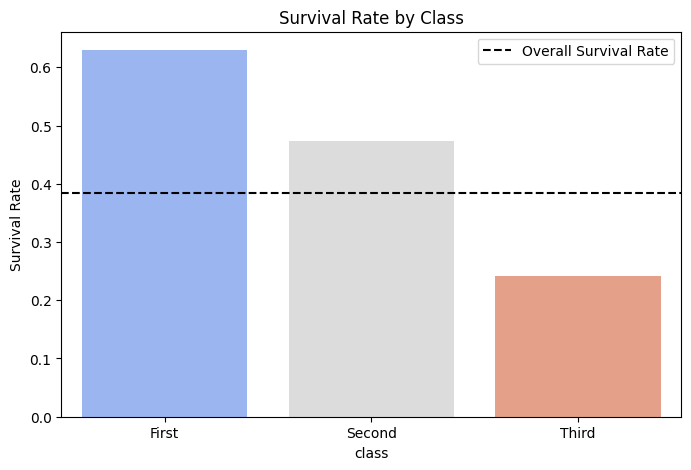

In [ ]:
# 전체 승객의 평균 생존률 계산
overall_survival_rate = titanic["survived"].mean()

# 각 등급별 생존률 계산
survival_rates_by_class = titanic.groupby("class", observed=False)["survived"].mean()

# 생존률 출력
print(f"Overall Survival Rate: {overall_survival_rate:.2f}")
print(survival_rates_by_class)

# 시각화: 좌석 등급별 생존률 막대 그래프
plt.figure(figsize=(8, 5))
sns.barplot(
    x=survival_rates_by_class.index,
    y=survival_rates_by_class.values,
    palette="coolwarm"
)
plt.axhline(
    overall_survival_rate,
    color='black',
    linestyle='dashed',
    label="Overall Survival Rate"
)
plt.title("Survival Rate by Class")
plt.ylabel("Survival Rate")
plt.legend()
plt.show()
